In [1]:
import os
import pandas as pd
import numpy as np
from trxtools import metaprofiles as meta
from trxtools import methods as ttm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

Load BigWig files and tRNA BED reference

In [10]:
bw_folder = '../04a_BigWig_dedup/'
bigwig_plus = [bw_folder + file for file in os.listdir(bw_folder) if file.endswith("dedup_CPM_plus.bw")
and "Cyclon" in file]
bigwig_minus = [bw_folder + file for file in os.listdir(bw_folder) if file.endswith("dedup_CPM_minus.bw")
and "Cyclon" in file]
bed_trna = pd.read_csv("../references/hg38-tRNAs.bed", sep='\t', header=None)

In [14]:
# Drop this contig as it's not included in the BigWigs
bed_trna = bed_trna[bed_trna[0] !='chr1_KI270713v1_random']
bed_introns = bed_trna[~bed_trna[11].str.split(",", expand=True)[2].isnull()]
bed_nointrons= bed_trna[bed_trna[11].str.split(",", expand=True)[2].isnull()]

Set flanks around tRNA genes

In [15]:
flank_5=50
flank_3=250

tRNA expression heatmap

In [60]:
df02 = meta.regionScore(
    bigwig_plus, bigwig_minus, bed_trna,
    agg_type='sum', flank_5=flank_5, flank_3=flank_3,
)
df02.columns = df02.columns.str.replace('../04a_BigWig_dedup/AG241010_','')
df02.columns = df02.columns.str.replace('_none_120mJ_','')
df02.columns = df02.columns.str.replace('_all_dedup_CPM_plus.bw','')

Text(0.5, 0.98, 'Flanked tRNA gene expression')

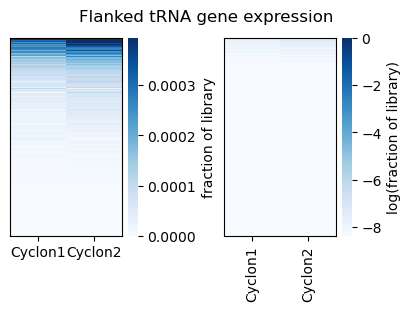

In [67]:
plotdata = df02.copy()
plotdata['mean'] = plotdata.mean(1)
plotdata = plotdata.sort_values('mean', ascending=False).drop(columns='mean')
fig, axs = plt.subplots(1,2, figsize=(4,3), sharey=True, layout='constrained')
sns.heatmap(plotdata, cmap='Blues', robust=True, vmin=0, ax=axs[0], cbar_kws={'label': 'fraction of library'})
sns.heatmap(np.log(plotdata.add(0.0001)), cmap='Blues', robust=True, vmin=0, ax=axs[1], cbar_kws={'label': 'log(fraction of library)'})
for ax in axs:
    ax.set(ylabel=None)
    ax.axvline(4, color='black')
    ax.tick_params(labelleft=False, left=False)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    
fig.suptitle("Flanked tRNA gene expression")

tRNA metagene profile

In [18]:
mm01 = meta.getMultipleMatrices(
    bigwig_plus,
    bigwig_minus,
    bed_trna,
    flank_5=flank_5,
    flank_3=flank_3,
    fill_na=True,
    pseudocounts=0.0001,
    normalize_libsize=True
)

mm02_3end = meta.getMultipleMatrices(
    bigwig_plus,
    bigwig_minus,
    bed_trna,
    align_3end=True,
    flank_5=flank_5,
    flank_3=flank_3,
    fill_na=True,
    pseudocounts=0.0001,
    normalize_libsize=True
)

<Axes: >

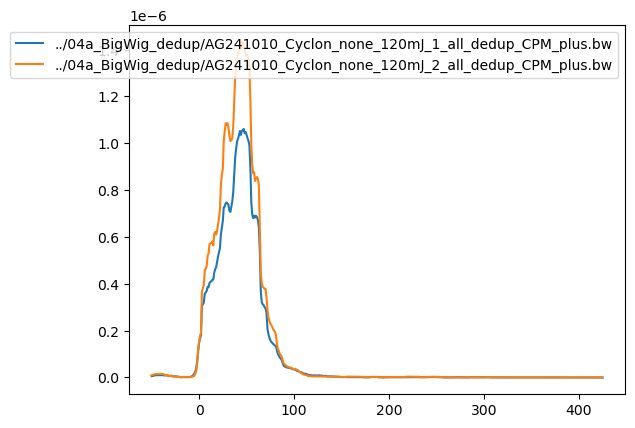

In [23]:
mp01 = meta.metaprofile(mm01, agg_type='mean', normalize_internal=False)
mp01.plot()